**Imports & set-up**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# **1. Data Cleaning**

In [ ]:
df = pd.read_csv("star-galaxy-quasar.csv", sep=",", skiprows=1)
display(df.head())
print(df.shape)

# Remove rows with missing value placeholders (-9999)
df = df[(df[["u", "g", "r", "i", "z"]] > -1000).all(axis=1)]

,objid,ra,dec,u,g,r,i,z,class,redshift
0,1237654669735231608,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,GALAXY,0.091934
1,1237651801233686770,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,GALAXY,0.065808
2,1237651800696881217,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,GALAXY,0.085327
3,1237654670272102476,149.128104,0.083621,20.33225,18.35458,17.40644,16.95075,16.59546,GALAXY,0.088111
4,1237651801233752148,149.153997,0.172473,19.67747,18.19364,17.51096,17.09774,16.89891,GALAXY,0.079039


(10000, 10)


In [3]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

class_counts = df["class"].value_counts(normalize=True) * 100
print(class_counts)

Shape: (9985, 10)

Data types:
objid         int64
ra          float64
dec         float64
u           float64
g           float64
r           float64
i           float64
z           float64
class        object
redshift    float64
dtype: object

Missing values:
objid       0
ra          0
dec         0
u           0
g           0
r           0
i           0
z           0
class       0
redshift    0
dtype: int64

Duplicate rows: 0
class
GALAXY    84.476715
STAR       8.662994
QSO        6.860290
Name: proportion, dtype: float64


**Drop objid and class columns (df1)**

In [4]:
## keep true labels for evaluation
real_y = None
if "class" in df.columns:
    real_y = df["class"].copy()

## drop identifier/ label columns
df1 = df.drop(columns=["objid", "class"], axis=1).copy()
df1.head()

,ra,dec,u,g,r,i,z,redshift
0,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,0.091934
1,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,0.065808
2,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,0.085327
3,149.128104,0.083621,20.33225,18.35458,17.40644,16.95075,16.59546,0.088111
4,149.153997,0.172473,19.67747,18.19364,17.51096,17.09774,16.89891,0.079039


**Feature Engineering**

In [5]:
## Compute color indices (differences between adjacent bands)
## - Often more discriminative than raw magnitudes
df1["u_g"] = df1["u"] - df1["g"]
df1["g_r"] = df1["g"] - df1["r"]
df1["r_i"] = df1["r"] - df1["i"]
df1["i_z"] = df1["i"] - df1["z"]

df1.head()

,ra,dec,u,g,r,i,z,redshift,u_g,g_r,r_i,i_z
0,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,0.091934,1.89183,0.97312,0.44642,0.33393
1,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,0.065808,1.74284,0.96594,0.53794,0.34925
2,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,0.085327,1.44872,0.85088,0.41556,0.32810
3,149.128104,0.083621,20.33225,18.35458,17.40644,16.95075,16.59546,0.088111,1.97767,0.94814,0.45569,0.35529
4,149.153997,0.172473,19.67747,18.19364,17.51096,17.09774,16.89891,0.079039,1.48383,0.68268,0.41322,0.19883


**Standardize the data (df2)**

In [6]:
scaler = StandardScaler()

column_names = df1.columns

df2 = scaler.fit_transform(df1)
df2 = pd.DataFrame(df2, columns=column_names)
display(df2.head())
df2.size

,ra,dec,u,g,r,i,z,redshift,u_g,g_r,r_i,i_z
0,-1.436058,-0.515742,-0.087846,-0.324400,-0.468335,-0.506938,-0.545713,-0.293298,0.356032,0.220105,0.144595,0.215130
1,-1.438349,0.264467,-1.088956,-1.464160,-1.763554,-1.888901,-1.911709,-0.372104,0.155886,0.205214,0.467887,0.275020
2,-1.434769,-0.435547,-0.074704,0.049660,0.071570,0.062395,0.016608,-0.313226,-0.239220,-0.033417,0.035582,0.192339
3,-1.437398,0.123744,0.274246,0.062061,-0.003898,-0.050251,-0.118169,-0.304830,0.471346,0.168298,0.177341,0.298632
4,-1.434975,0.248338,-0.145517,-0.067792,0.092425,0.085447,0.155928,-0.332193,-0.192055,-0.382258,0.027316,-0.313010


119820

# **2. Exploratory Data Analysis**

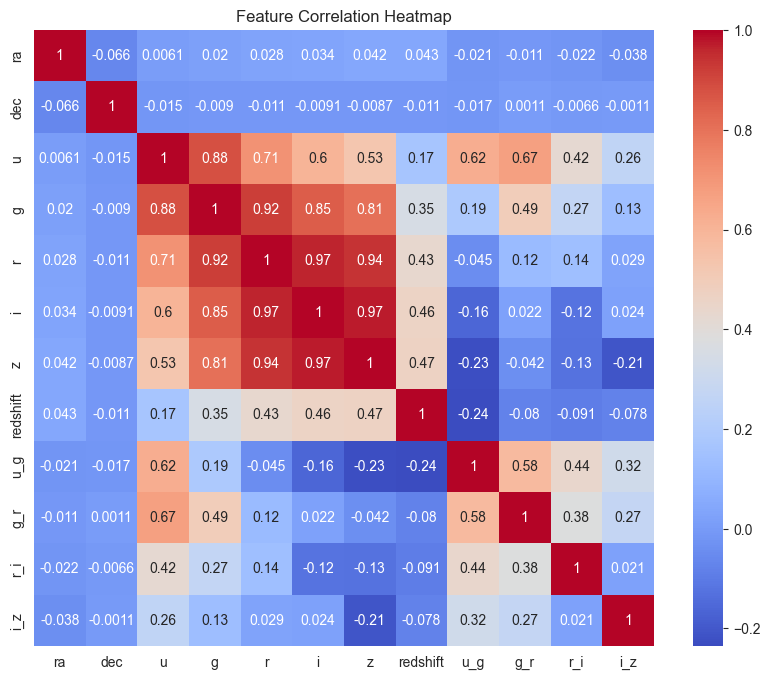

In [7]:
plt.figure(figsize=(10, 8))

corr = df2.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

The photometric magnitude features (u, g, r, i, z) exhibit very strong positive correlations (generally above 0.8), indicating that they capture very similar information about an object’s brightness across different wavelengths. With With high redundancy in such features, Principal Component Analysis (PCA) becomes especially useful in dimensionality reduction, such that we only consider the most prominent features in our analysis.

Engineered color index features (u_g, g_r, r_i, i_z) display more moderate correlations with the raw magnitudes and among themselves. They also show some negative correlations with certain bands. This indicates that color indices provide complementary information and are likely to be more discriminative for distinguishing between different types of astronomical objects.

In contrast, the spatial features (ra, dec) show near-zero correlation with most other variables, suggesting they are largely independent and may not contribute significantly to clustering. Redshift shows moderate correlation with some photometric features, implying it may still carry useful information related to object distance and type. 

Overall, the heatmap suggests that combining color indices with selected magnitude or redshift features could improve clustering performance while avoiding redundancy.

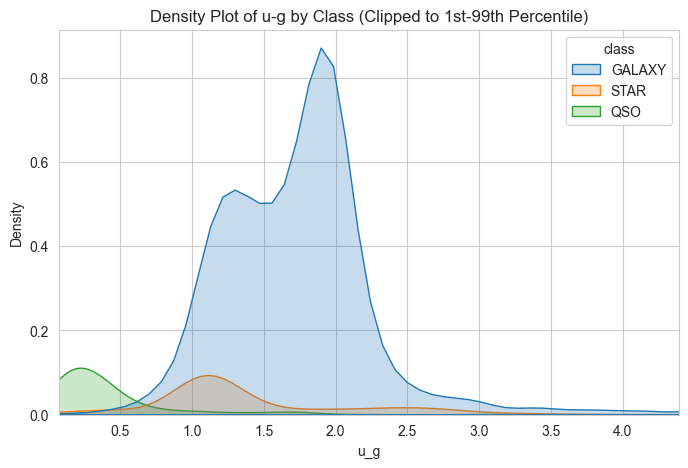

In [8]:
df_plot = df1.copy()
df_plot["class"] = real_y.values

## 1D density plot of u-g by class
x_low, x_high = df_plot["u_g"].quantile([0.01, 0.99])

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_plot, x="u_g", hue="class", fill=True)
plt.xlim(x_low, x_high)
plt.title("Density Plot of u-g by Class (Clipped to 1st-99th Percentile)")
plt.show()


The density plot of the u-g color index shows distinct but overlapping distributions across the 3 object classes. QSOs tend to have lower u-g values, indicating that they are generally bluer, while galaxies exhibit higher values and a broader spread. Stars lie between these 2 groups but show significant overlap with galaxies.

Overall, this reveals that while u-g is a useful feature for distinguishing object types, it is not sufficient on its own for clear separation, highlighting the need for additional features to improve clustering performance. 

/var/folders/32/q3tnvx250vscqz7f2nbpltvm0000gn/T/ipykernel_50055/4143978604.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df_plot.groupby("class", group_keys=False).apply(


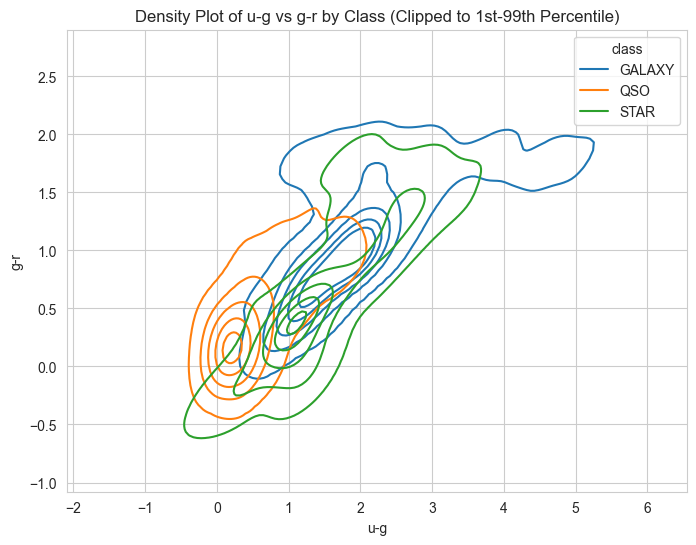

In [9]:
# Group by "class" (stop class frm becoming idx col) -> Randomly sample up to 1500 rows per group
sample_df = df_plot.groupby("class", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1500), random_state=42)
)
x_low, x_high = df_plot["u_g"].quantile([0.01, 0.99])
y_low, y_high = df_plot["g_r"].quantile([0.01, 0.99])

x_range = x_high - x_low
y_range = y_high - y_low

plt.figure(figsize=(8,6))

sns.kdeplot(
    data=sample_df,
    x="u_g",
    y="g_r",
    hue="class",
    levels=6,
    fill=False
)

plt.xlim(x_low - 0.5*x_range, x_high + 0.5*x_range)
plt.ylim(y_low - 0.5*y_range, y_high + 0.5*y_range)

plt.title("Density Plot of u-g vs g-r by Class (Clipped to 1st-99th Percentile)")
plt.xlabel("u-g")
plt.ylabel("g-r")
plt.show()


The contour plot of u-g vs g-r illustrates the distribution of object class in colour-colour space. QSOs are concentrated in the lower range of both u-g and g-r while galaxies are clustered toward higher values and stars occupy an intermediate region. 

However, there is still significant overlap among the classes, indicating that color indices alone are insufficient for clear separation. This highlights the importance of incorporating other features, such as redshift (distance relative to Earth) to achieve better discrimination between classes. 

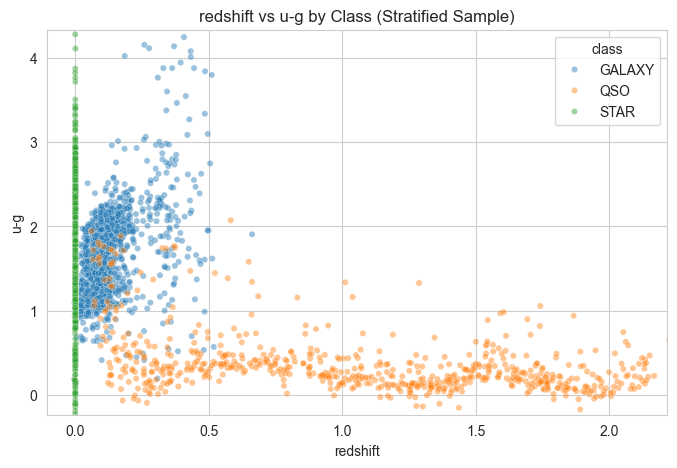

In [10]:
x_low, x_high = sample_df["redshift"].quantile([0.01, 0.99])
y_low, y_high = sample_df["u_g"].quantile([0.01, 0.99])

x_range = x_high - x_low
y_range = y_high - y_low

sns.scatterplot(
    data=sample_df,
    x="redshift",
    y="u_g",
    hue="class",
    alpha=0.45,
    s=20
)
plt.xlabel("redshift")
plt.ylabel("u-g")
plt.title("redshift vs u-g by Class (Stratified Sample)")
plt.xlim(x_low - 0.05*x_range, x_high + 0.05*x_range)
plt.ylim(y_low - 0.05*y_range, y_high + 0.05*y_range)
plt.show()

The scatterplot of redshift versus u-g reveals much clearer separation between astronomical object classes when combining color and distance-related information. Stars are concentrated near zero redshift, reflecting their proximity to Earth. QSOs tend to have higher redshift and lower u-g values while galaxies have low to moderate redshift values and higher u-g values. 

This demonstrates that redshift is a highly informative feature that greatly improves separability when combined with color indices. The clear distinction of QSOs and stars suggests that incoporating redshift will be crucial for effective clustering. 

# **3. Principle Component Analysis**

*   PCA helps to visualise high-dimensional data by projecting it into lower dimensional spcae (e.g, 2D/ 3D graph)


*   All Principle Components are uncorrelated
* PC1 has the highest variance (most amt of info from the original dataset retained in PC1)

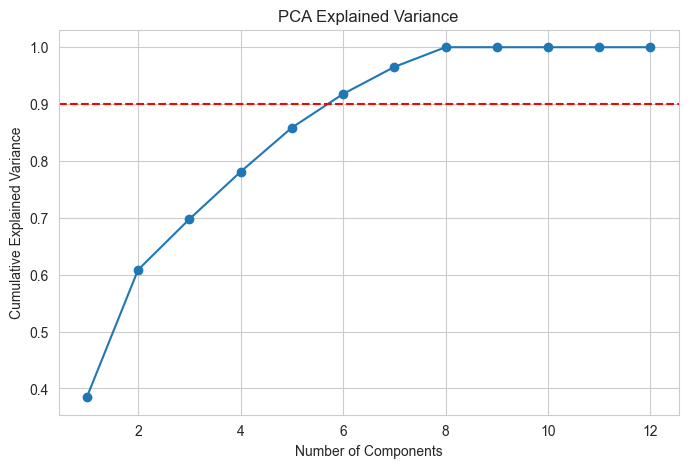

Components for 90% variance captured: 6


In [11]:
pca_full = PCA()
pca_full.fit(df2)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.axhline(y=0.90, color='r', linestyle='--')
plt.show()

### number of components for 90% variance captured
n_components_95 = np.argmax(explained_variance >= 0.90) + 1
print("Components for 90% variance captured:", n_components_95)

# Most of the dataset's info can be retained using ~6 Principle Components,
# indicating redundancy among current features

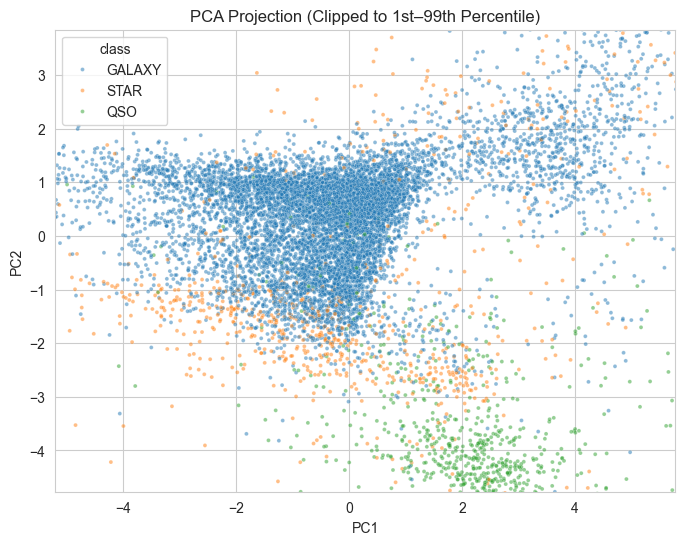

In [12]:
## Reduce high-dimensionality data (12 features) to 2 dimensions
# PC1 (most impt direction) & PC2 (second most impt)
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(df2)

plot_df = pd.DataFrame({
    "PC1": X_2d[:, 0],
    "PC2": X_2d[:, 1],
    "class": real_y.values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="class", alpha=0.5, s=8)

x_low, x_high = plot_df["PC1"].quantile([0.01, 0.99])
y_low, y_high = plot_df["PC2"].quantile([0.01, 0.99])

plt.xlim(x_low, x_high)
plt.ylim(y_low, y_high)

plt.title("PCA Projection (Clipped to 1st–99th Percentile)")
plt.show()

The PCA projection onto the first two principal components reveals partial separation between the three object classes. QSOs form a relatively distinct cluster at lower values of PC2, indicating that they have significantly different feature characteristics compared to stars and galaxies. This suggests that the principal components successfully capture key variance related to QSO properties.

In contrast, stars and galaxies exhibit substantial overlap in the PCA space, particularly along PC1. This indicates that their photometric properties are more similar, making them harder to separate using linear combinations of features alone.

Overall, the plot shows that the dataset is not linearly separable in lower dimensions, and clustering algorithms may require multiple features or non-linear decision boundaries to effectively distinguish between object types.

In [13]:
## Show how impt each original feature is to each principal component/ how much they contribute to PCA

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca_full.components_))],
    index=column_names
)
display(loadings.head(10))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
ra,0.016228,-0.038200,0.696671,0.029154,0.712529,-0.034610,0.055671,-0.009036,1.451648e-17,-5.686785e-17,4.218627e-17,1.355032e-17
dec,-0.007623,-0.003228,-0.688437,-0.241329,0.683185,0.014878,0.010937,0.025757,-1.276416e-16,1.694963e-17,-2.391890e-16,1.553323e-16
u,0.396340,0.307663,0.008275,-0.009599,0.006778,-0.053622,-0.094102,0.178265,-1.326378e-01,-1.301870e-01,1.005419e-01,8.123375e-01
g,0.457162,0.072356,-0.009626,-0.017264,-0.000990,-0.056407,-0.010807,-0.211256,8.056666e-01,2.956076e-01,4.322997e-03,-3.077856e-02
r,0.447664,-0.121031,-0.016431,-0.020190,-0.021487,-0.090244,0.224121,0.015857,-4.865440e-01,6.562925e-01,-2.169234e-01,-1.033584e-01
i,0.425180,-0.218291,-0.042886,0.121859,0.003904,-0.156218,0.060947,0.054770,-1.062579e-03,-5.919925e-01,-5.895799e-01,-1.602737e-01
z,0.406153,-0.276567,-0.004534,-0.063395,-0.021989,-0.187474,-0.040509,0.079112,-1.280304e-01,-2.362049e-01,7.486764e-01,-2.797861e-01
redshift,0.211624,-0.250461,0.026189,0.029561,0.016138,0.913910,-0.193339,0.134360,1.302549e-16,3.272974e-16,-2.541150e-16,-5.938366e-16
u_g,0.069365,0.524228,0.033367,0.008630,0.015850,-0.018448,-0.179194,0.725280,6.329755e-02,6.212798e-02,-4.798072e-02,-3.876646e-01
g_r,0.167676,0.458365,0.012234,0.001061,0.045811,0.058099,-0.532154,-0.578716,-2.724313e-01,-7.475938e-02,-3.275985e-02,-2.391242e-01


In [14]:
for i in range(3):  # first 3 PCs
    print(f"\nTop features for PC{i+1}:")
    print(loadings[f"PC{i+1}"].abs().sort_values(ascending=False).head(5))


Top features for PC1:
g    0.457162
r    0.447664
i    0.425180
z    0.406153
u    0.396340
Name: PC1, dtype: float64

Top features for PC2:
u_g    0.524228
g_r    0.458365
r_i    0.371352
u      0.307663
z      0.276567
Name: PC2, dtype: float64

Top features for PC3:
ra     0.696671
dec    0.688437
i_z    0.161982
r_i    0.101121
i      0.042886
Name: PC3, dtype: float64




*   **PC1: i, g, z, u, r → all high** (PC1 represents overall brightness/ magnitude since all photometric bands contribute similarly)
*   **PC2: u_g, g_r, r_i → highest** (PC2 captures color differences, proving feature engineering is useful)
* **PC3: ra and dec are dominant** (PC3 captures spatial information)

